In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import xgboost as xgb

import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score

import warnings
from pandas.errors import PerformanceWarning

In [180]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [181]:
print('train shape', train.shape, sep='\n')
print('test shape', test.shape, sep='\n')

print(train)

train shape
(200000, 202)
test shape
(200000, 201)
             ID_code  target    var_0   var_1    var_2   var_3    var_4  \
0            train_0       0   8.9255 -6.7863  11.9081  5.0930  11.4607   
1            train_1       0  11.5006 -4.1473  13.8588  5.3890  12.3622   
2            train_2       0   8.6093 -2.7457  12.0805  7.8928  10.5825   
3            train_3       0  11.0604 -2.1518   8.9522  7.1957  12.5846   
4            train_4       0   9.8369 -1.4834  12.8746  6.6375  12.2772   
...              ...     ...      ...     ...      ...     ...      ...   
199995  train_199995       0  11.4880 -0.4956   8.2622  3.5142  10.3404   
199996  train_199996       0   4.9149 -2.4484  16.7052  6.6345   8.3096   
199997  train_199997       0  11.2232 -5.0518  10.5127  5.6456   9.3410   
199998  train_199998       0   9.7148 -8.6098  13.6104  5.7930  12.5173   
199999  train_199999       0  10.8762 -5.7105  12.1183  8.0328  11.5577   

          var_5   var_6    var_7  ...  var_190  

In [182]:
# Function to check uniqueness and store the result in a new column
def check_uniqueness(column):
    return column.map(column.value_counts() == 1).astype(int)

def make_unique(df):
    warnings.simplefilter(action='ignore', category=PerformanceWarning)

    df_unique = {}
    
    # Apply the function to each column
    for col in df.columns:
        if col != 'ID_code' and col != 'target':
            df_unique[col] = check_uniqueness(df[col])

    warnings.resetwarnings()

    return pd.DataFrame(df_unique)

train_unique = make_unique(train)

print(train_unique)

test_unique = make_unique(test)

print(test_unique)

        var_0  var_1  var_2  var_3  var_4  var_5  var_6  var_7  var_8  var_9  \
0           0      0      0      0      0      1      0      0      0      0   
1           0      0      0      0      0      1      0      0      0      0   
2           0      1      0      0      0      0      0      0      1      0   
3           0      0      0      0      0      0      0      0      0      0   
4           0      0      0      0      0      1      0      1      1      0   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
199995      0      1      0      1      0      1      0      1      0      0   
199996      0      0      1      0      1      1      0      0      0      0   
199997      0      0      0      0      0      1      0      0      1      0   
199998      0      1      1      0      0      0      0      0      0      0   
199999      0      0      0      0      0      0      0      0      1      0   

        ...  var_190  var_191  var_192 

In [183]:
num_rows = 1_000_000

x_train_ = train.iloc[:num_rows, 2:].values
y_train = train.iloc[:num_rows, 1].values
x_test_ = test.iloc[:num_rows, 1:].values

x_train_unique = train_unique.iloc[:num_rows, :].values
x_test_unique = test_unique.iloc[:num_rows, :].values

print(x_train_unique)

scaler = preprocessing.StandardScaler().fit(x_train_)
x_train_scaled = scaler.transform(x_train_)

scaler = preprocessing.StandardScaler().fit(x_test_)
x_test_scaled = scaler.transform(x_test_)

num_components = 10

pca = PCA(n_components=num_components)
pca.fit(x_train_scaled)

x_train_pca = pca.transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

pca.fit(x_train_unique)

x_train_unique_pca = pca.transform(x_train_unique)
x_test_unique_pca = pca.transform(x_test_unique)

print(x_train_unique_pca)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 1 1 ... 0 0 1]
 [0 0 0 ... 0 0 1]]
[[ 0.80479597  0.22579895 -0.20480749 ...  0.66920758 -0.15997165
   0.1028022 ]
 [ 0.14979409 -0.06101497 -0.39489465 ... -0.23923589  0.05985983
   0.36878782]
 [ 0.00314705 -1.04941925 -0.02362702 ...  0.56750709 -0.20925722
  -0.62529416]
 ...
 [ 0.28777223 -0.43982116 -0.38539811 ... -0.46227864  0.32247667
   0.17466033]
 [ 0.39407231 -0.44336487  0.69242883 ... -0.10192183 -0.9111458
   0.27270789]
 [-0.63700225  0.19139424  0.58890076 ...  0.14660397 -0.55565371
  -0.94242475]]


In [184]:
x_train = pd.DataFrame(x_train_pca, columns=[f'var{i}' for i in range(num_components)])
x_test = pd.DataFrame(x_test_pca, columns=[f'var{i}' for i in range(num_components)])

x_train_unique = pd.DataFrame(x_train_unique_pca, columns=[f'var{i}_unique' for i in range(num_components)])
x_test_unique = pd.DataFrame(x_test_unique_pca, columns=[f'var{i}_unique' for i in range(num_components)])

print(x_train_unique)

x_train_merged = pd.concat([x_train, x_train_unique], axis=1)
x_test_merged = pd.concat([x_test, x_test_unique], axis=1)

print(x_train_merged)
# print(x_test_merged)

        var0_unique  var1_unique  var2_unique  var3_unique  var4_unique  \
0          0.804796     0.225799    -0.204807     0.099358     0.621651   
1          0.149794    -0.061015    -0.394895     0.490709    -0.814828   
2          0.003147    -1.049419    -0.023627    -0.904578     0.457076   
3          0.235587     0.133368     0.968396     0.314974     0.212532   
4          0.097790    -0.424565     0.451171    -0.450447     0.573156   
...             ...          ...          ...          ...          ...   
199995     0.507654     0.543386     0.154255    -0.445688     0.285968   
199996    -0.021884    -0.168998     0.028584    -1.073077     0.543708   
199997     0.287772    -0.439821    -0.385398    -0.121116     0.320436   
199998     0.394072    -0.443365     0.692429    -0.962139     0.349457   
199999    -0.637002     0.191394     0.588901     0.456399     0.079995   

        var5_unique  var6_unique  var7_unique  var8_unique  var9_unique  
0         -0.147504     0

In [195]:
x_train_merged_np = x_train_merged.iloc[:, :].values
# y_train_np = y_train.iloc[:num_rows, 1].values

# Convert your data to PyTorch tensors
x_train_tensor = torch.tensor(x_train_merged_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Create a TensorDataset
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

# Split the dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [199]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(num_components * 2, 16)  # First hidden layer
        # self.fc2 = nn.Linear(40, 20)  # Second hidden layer
        self.fc3 = nn.Linear(16, 1)  # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))
        # x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))  # Sigmoid for binary classification
        return x

# Instantiate the model
model = SimpleNN()

In [200]:
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [201]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the parameter gradients
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()  # Backpropagation
        optimizer.step()  # Update the weights

        running_loss += loss.item()

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}')

    # Optionally, evaluate on the validation set
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            val_loss += loss.item()
    print(f'Validation Loss: {val_loss/len(val_loader)}')


Epoch 1/5, Loss: 0.25512946386784313
Validation Loss: 0.23767614843547344
Epoch 2/5, Loss: 0.23448421523794533
Validation Loss: 0.23697194786965847
Epoch 3/5, Loss: 0.2336838809493929
Validation Loss: 0.23721407494544983
Epoch 4/5, Loss: 0.23352318992465734
Validation Loss: 0.2367180284321308
Epoch 5/5, Loss: 0.2332457250609994
Validation Loss: 0.2358974996238947


In [203]:
x_test_merged_np = x_test_merged.iloc[:, :].values

# Convert test data to PyTorch tensor
x_test_tensor = torch.tensor(x_test_merged_np, dtype=torch.float32)

# Make predictions
model.eval()
with torch.no_grad():
    test_preds = model(x_test_tensor).squeeze().numpy()

# test_preds now contains the predicted probabilities for the test data
print(x_test_tensor.shape)
print(test_preds.shape)
print(test_preds)
y_pred = np.array([0 if x < 0.5 else 1 for x in test_preds])

ones = [x for x in y_pred if x == 1]
zeros = [x for x in y_pred if x == 0]

print(y_pred)
print(len(y_pred))
print(len(ones))
print(len(zeros))

torch.Size([200000, 20])
(200000,)
[0.2779299  0.1996708  0.04344486 ... 0.00213947 0.0369368  0.10753373]
[0 0 0 ... 0 0 0]
200000
6480
193520


In [204]:
pred_num_rows = len(y_pred)

# Generate the ID_code and target columns
data = {
    'ID_code': [f'test_{i}' for i in range(pred_num_rows)],
    'target': y_pred
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
csv_filename = 'output.csv'
df.to_csv(csv_filename, index=False)

print(f"CSV file '{csv_filename}' generated successfully!")

CSV file 'output.csv' generated successfully!


In [63]:
# Get the principal components (eigenvectors)
components = pca.components_

# Get the explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_

In [66]:
feature_names = np.array([f'var{i}' for i in range(200)])  # Replace with actual feature names
component_df = pd.DataFrame(components, columns=feature_names)
print(component_df)

        var0      var1      var2      var3      var4      var5      var6  \
0  -0.113597 -0.104157 -0.121453 -0.015592 -0.007613 -0.044729 -0.131468   
1   0.043750  0.008162  0.010329  0.150598  0.011088 -0.099539 -0.041088   
2  -0.084980 -0.035149 -0.007964 -0.020716 -0.118882  0.010152 -0.029953   
3  -0.082712 -0.044227 -0.060638  0.011923 -0.135716  0.051260 -0.023457   
4   0.050322 -0.065474 -0.001771  0.082787  0.040367 -0.061982 -0.068438   
5  -0.061948 -0.179432 -0.052856 -0.083395  0.088793  0.029720  0.034552   
6  -0.112746 -0.013854 -0.122709  0.044323  0.026208  0.019095 -0.053174   
7   0.024718  0.002075  0.160105  0.067489  0.042909  0.062237  0.017352   
8  -0.066136  0.037393  0.031215 -0.038052  0.062982 -0.029114 -0.033486   
9   0.006924 -0.095329 -0.170455  0.056805 -0.040212 -0.010256  0.056384   
10  0.005587  0.010061 -0.081178  0.021414 -0.060650 -0.040852 -0.120778   
11 -0.011023 -0.069186 -0.063155 -0.025474  0.042580 -0.193070  0.075221   
12  0.021083

In [67]:
# Calculate absolute values of the loadings
absolute_loadings = np.abs(components)

# Sum the absolute loadings across all components to get a measure of total importance for each feature
feature_importance = np.sum(absolute_loadings, axis=0)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)

    Feature  Importance
151  var151    1.504185
49    var49    1.492007
123  var123    1.462945
158  var158    1.453388
94    var94    1.449792
..      ...         ...
16    var16    0.775233
70    var70    0.762888
37    var37    0.716772
35    var35    0.711103
25    var25    0.678321

[200 rows x 2 columns]


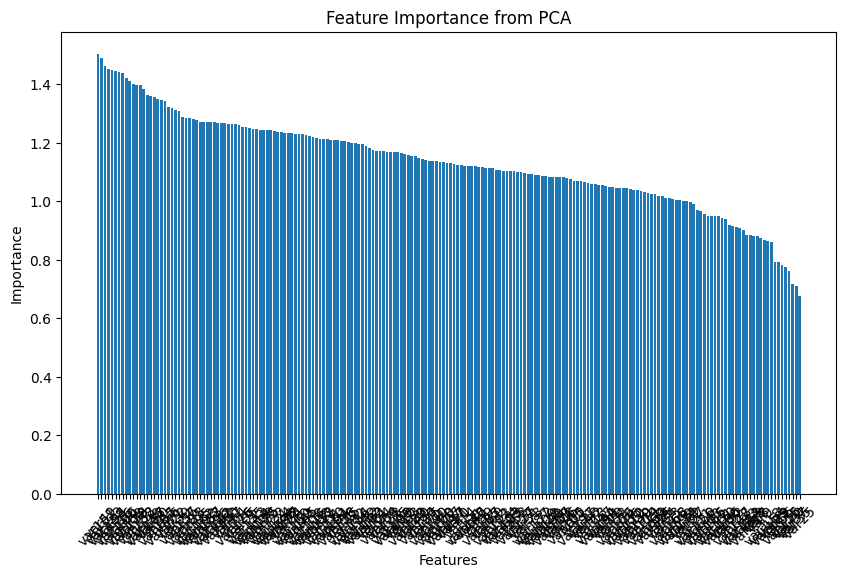

In [70]:
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance from PCA')
plt.xticks(rotation=45)
plt.show()

In [95]:
# Instantiate the model
model = TabNetClassifier()

# Fit the model
model.fit(x_train, y_train,
          max_epochs=5,
          patience=50)

# Predict and evaluate
y_pred = model.predict(x_test)

print(y_pred)

/opt/anaconda3/envs/kaggle/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/opt/anaconda3/envs/kaggle/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.26959 |  0:00:09s
epoch 1  | loss: 0.23906 |  0:00:19s
epoch 2  | loss: 0.23792 |  0:00:28s
epoch 3  | loss: 0.23774 |  0:00:38s
epoch 4  | loss: 0.23673 |  0:00:47s
[0 0 0 ... 0 0 0]


In [96]:
ones = [x for x in y_pred if x == 1]
zeros = [x for x in y_pred if x == 0]

print(y_pred)
print(len(y_pred))
print(len(ones))
print(len(zeros))

[0 0 0 ... 0 0 0]
200000
5941
194059


In [97]:
pred_num_rows = len(y_pred)

# Generate the ID_code and target columns
data = {
    'ID_code': [f'test_{i}' for i in range(pred_num_rows)],
    'target': y_pred
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
csv_filename = 'output.csv'
df.to_csv(csv_filename, index=False)

print(f"CSV file '{csv_filename}' generated successfully!")

CSV file 'output.csv' generated successfully!
